In [2]:
import pandas as pd
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import itertools
from collections import Counter

import netrd

from sklearn.metrics.pairwise import cosine_similarity


## Question 1 - Network reconstruction

In [100]:
iterations = range(20)

# ground truth network
G = nx.barabasi_albert_graph(n=64, m=3, seed=867)

# dynamic model
SISModel = netrd.dynamics.SISModel()

X = [SISModel.simulate(G, L=1000, num_seeds=25, beta=0.25, mu=0.15) for _ in iterations]


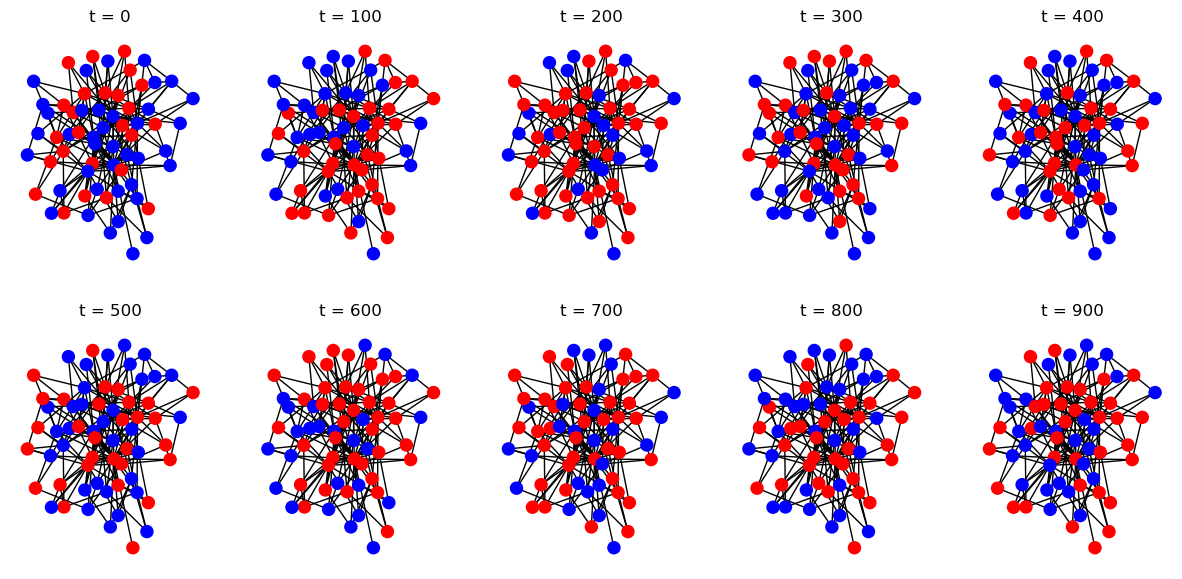

In [101]:
df = pd.DataFrame(X[0]).astype(int)

pos = nx.spring_layout(G, seed=867)

fig, ax = plt.subplots(2, 5, figsize=(15, 7))

indeces = itertools.product(range(2), range(5))

for i, state in zip(indeces, range(0, 1000, 100)):
    nx.draw(G,
            pos=pos,
            node_size=75,
            node_color=["red" if i == 1 else "blue" for i in df[state]],
            ax=ax[i]
    )
    ax[i].set_title(f"t = {state}")

plt.savefig("figures/1_sis_timeseries.png")

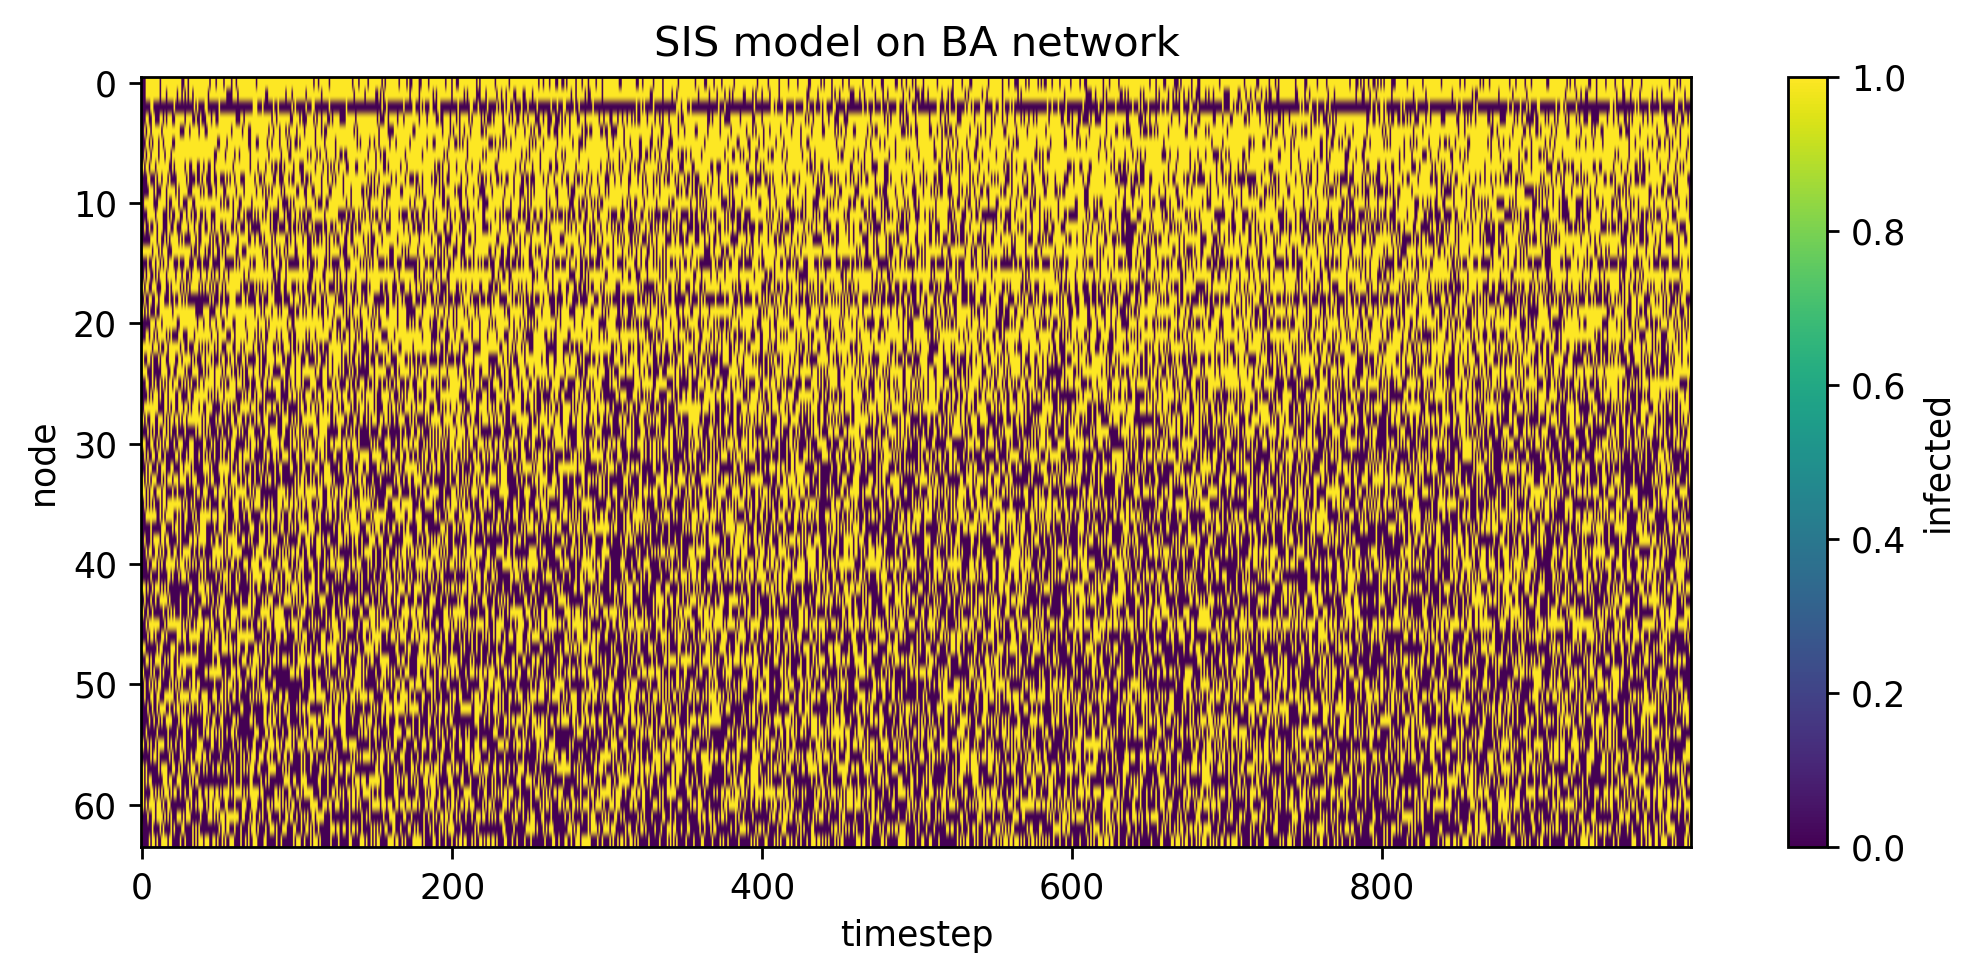

In [102]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4), dpi=250)
im = ax.imshow(X[0], aspect="auto")

ax.set_title("SIS model on BA network")
ax.set_xlabel("timestep")
ax.set_ylabel("node")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("infected")

plt.savefig("figures/1_sis_timeplot.png")

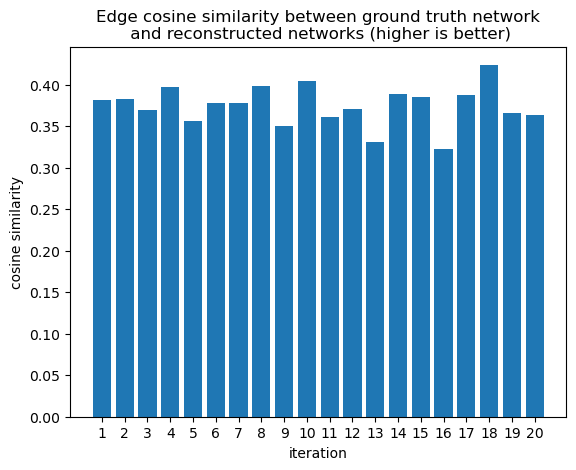

In [105]:
def graph_edge_cosine_similarity(G1, G2):
    
    # triu prevents double counting of edges and self loops
    G1_edgelist = np.triu(nx.to_numpy_array(G1)).flatten()
    G2_edgelist = np.triu(nx.to_numpy_array(G2)).flatten()

    return cosine_similarity([G1_edgelist], [G2_edgelist]).flatten()[0]


reconstructor = netrd.reconstruction.FreeEnergyMinimization()

correctness = []
Rs = []
for i in iterations:

    R = reconstructor.fit(
        TS=X[i], 
        threshold_type="degree", 
        avg_k=np.mean([G.degree[n] for n in G.nodes])
    )
    Rs.append(R.to_undirected())

    correctness.append(graph_edge_cosine_similarity(G, R))



fig, ax = plt.subplots(1, 1)

ax.bar(iterations, correctness)
ax.set_title("Edge cosine similarity between ground truth network\n and reconstructed networks (higher is better)")
ax.xaxis.set_major_locator(MaxNLocator(integer=True, steps=[5]))
# ax.set_ybound(-0.5, 0.5)
ax.set_xticks(np.arange(len(iterations)), np.arange(1, len(iterations) + 1))
ax.set_xlabel("iteration")
ax.set_ylabel("cosine similarity")
plt.savefig("figures/1_cossim_g_r.png")

/tmp/ipykernel_82099/3230338886.py:25: UserWarning: Adding colorbar to a different Figure <Figure size 2500x1000 with 2 Axes> than <Figure size 900x700 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, ax=ax)


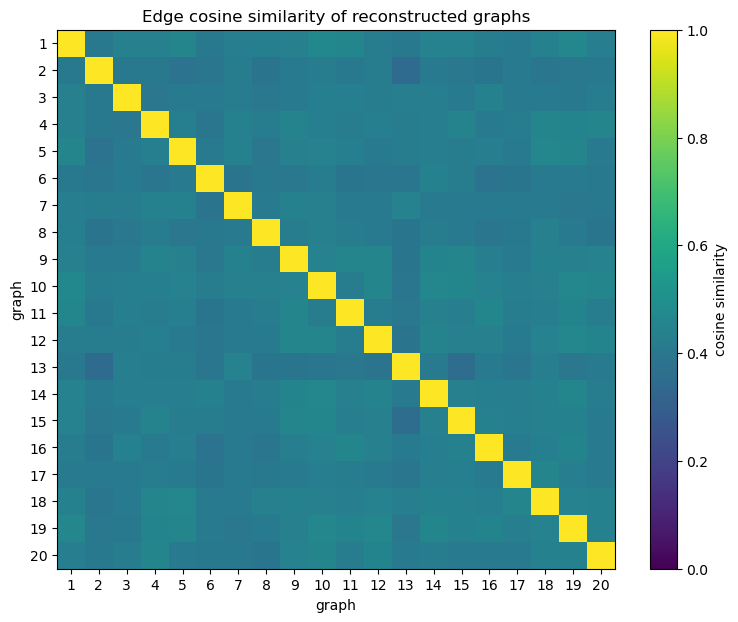

In [107]:
r_sim = np.identity(len(iterations))

for i, j in itertools.combinations(iterations, 2):
    r_sim[i, j] = graph_edge_cosine_similarity(Rs[i], Rs[j])

r_sim += np.triu(r_sim, k=1).T



fig, ax = plt.subplots(1, 1, figsize=(9, 7))

ax.imshow(r_sim, vmin=0, vmax=1, aspect="auto")

ax.yaxis.set_major_locator(MaxNLocator(integer=True))   
ax.xaxis.set_major_locator(MaxNLocator(integer=True))   

ax.set_xticks(np.arange(len(iterations)), np.arange(1, len(iterations) + 1))
ax.set_yticks(np.arange(len(iterations)), np.arange(1, len(iterations) + 1))

ax.set_title("Edge cosine similarity of reconstructed graphs")
ax.set_xlabel("graph")
ax.set_ylabel("graph")


cbar = fig.colorbar(im, ax=ax)
cbar.set_label("cosine similarity")

plt.savefig("figures/1_cossim_r_r.png")

## Question 2 - Big data

In [108]:

def bloom_filter_length(n, epsilon):

    m = -1 * (n * np.log(epsilon)) / np.pow(np.log(2), 2)

    return int(m)



def get_hash_mod(u, v, m):

    # always make u lower
    if u > v:
        u, v = v, u

    bin = hash(f"{u}+{v}") % m

    return bin


G_er = nx.erdos_renyi_graph(1000, 0.05)

bloom_filter_length(1000, 0.05)

6235

In [133]:


n = 100
p = 0.05
epsilon = 0.05

m = bloom_filter_length(n, epsilon)

G_er = nx.erdos_renyi_graph(n, p)

bloom_filter = np.zeros(m, dtype=int)

# for _ in 

# initial_collisions = 0

# for (u, v) in G_er.edges:
#     hash_mod = get_hash_mod(u, v, m)

#     if bloom_filter[hash_mod] == 1:
#         initial_collisions += 1
    
#     bloom_filter[get_hash_mod(u, v, m)] = 1

# print(f"{initial_collisions=}")

G = nx.empty_graph(10)

collisions = 0

# add edges
for _ in range(1000):

    while True:
        u, v = np.random.randint(0, n + 1, 2)
        print(u, v)

        if (u, v) not in G.edges:
            G.add_edge(u, v)

            hash_mod = get_hash_mod(u, v, m)

            if bloom_filter[hash_mod] == 1:
                collisions += 1
                print(f"{collisions=}")

            print()
            break
print(collisions)



63 17

25 17

66 16

76 54

78 37

51 89

51 76

74 24

38 31

86 88

10 92

47 39

72 17

69 3

67 74

92 9

76 42

31 61

11 92

61 73

84 65

88 67

88 64

69 14

34 19

66 29

4 8

52 37

44 14

63 67

71 21

23 59

77 42

84 48

66 70

27 24

85 22

85 14

95 28

18 97

5 30

29 75

67 97

55 10

84 36

35 25

20 24

95 97

73 41

15 85

64 93

47 10

90 91

66 99

42 47

50 40

67 74
64 22

56 15

13 51

19 65

41 57

8 29

28 2

14 28

35 85

19 84

100 29

20 61

92 77

35 61

37 53

14 7

30 82

47 53

22 92

16 94

28 32

94 71

60 49

61 47

55 71

67 80

7 69

61 53

2 86

28 22

62 42

56 88

4 1

45 3

36 90

24 95

86 47

85 23

80 95

47 84

76 85

32 57

29 45

30 93

63 23

67 54

69 100

40 80

50 9

99 15

70 49

27 74

67 31

64 11

84 58

39 16

61 35
53 10

85 0

90 45

32 51

60 21

96 86

19 89

42 60

95 68

72 88

61 26

84 61

81 89

54 52

13 62

20 44

57 31

43 86

81 13

88 44

9 86

75 82

34 67

98 1

46 30

91 9

60 56

74 8

13 27

7 30

59 86

30 66

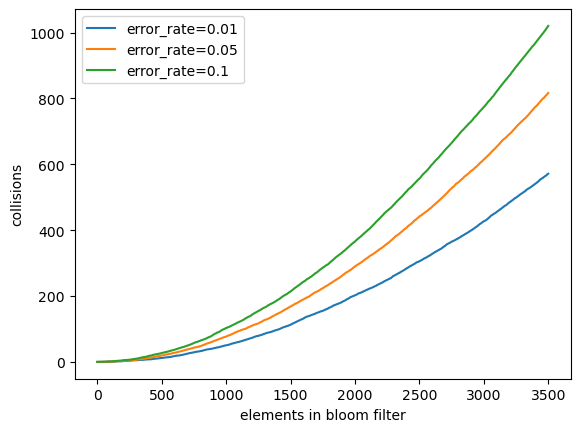

In [156]:

expected_edges = 1000
timesteps = 3500
iters = 10
error_rates = [0.01, 0.05, 0.1]

fig, ax = plt.subplots(1, 1)

for error_rate in error_rates:
    collisions = np.zeros(timesteps)
    for _ in range(iters):
        G = nx.empty_graph(1000)

        bloom_filter = np.zeros(bloom_filter_length(expected_edges, error_rate))

        total_collisions = 0

        for t in range(timesteps):

            while True:
                u, v = np.random.randint(0, len(G), 2)

                if (u, v) not in G.edges:
                    G.add_edge(u, v)

                    hash_mod = get_hash_mod(u, v, len(bloom_filter))

                    if bloom_filter[hash_mod] == 1:
                        total_collisions += 1
                    else:
                        bloom_filter[hash_mod] = 1

                    break
            collisions[t] += total_collisions


    ax.plot(collisions / iters, label=f"{error_rate=}")

ax.set_xlabel("elements in bloom filter")
ax.set_ylabel("collisions")


plt.legend()

## Question 3 - ABMs

In [4]:
# ============================================================
# PART 1. NK LANDSCAPE GENERATOR
# ============================================================

def generate_nk_landscape(N=20, K=5, seed=None, apply_paper_skew=True):
    """
    Create one NK landscape and return a fitness function on binary strings.

    This is the "environment" or "problem space" that agents search over.
    It does NOT implement the agent-based model itself. It only defines
    how good or bad each binary-string solution is.

    --------------------------------------------------------------------
    BIG PICTURE
    --------------------------------------------------------------------
    In an NK landscape:
        - N is the length of the binary string.
        - K controls ruggedness.

    Each solution is a binary string such as:
        (0, 1, 1, 0, 0, 1, ...)

    The score of a solution is built from N local contributions.
    Each local contribution depends on:
        - the bit at one locus i
        - and K other loci that interact with it

    As K increases, the landscape usually becomes more rugged:
        - more local optima
        - more path dependence
        - more chance of getting stuck

    --------------------------------------------------------------------
    CONNECTION TO LAZER & FRIEDMAN (2007)
    --------------------------------------------------------------------
    This follows the standard NK setup described in Appendix A of the paper.

    The paper:
        - uses an NK landscape as the search environment,
        - normalizes performance by the maximum of the landscape,
        - and discusses an r^8 monotonic transformation in Appendix A.

    This function:
        1. builds the local dependency structure,
        2. creates random contribution tables,
        3. computes the score of every possible bitstring,
        4. normalizes by the exact global maximum,
        5. optionally applies the paper-style r^8 transformation.

    --------------------------------------------------------------------
    IMPORTANT DISTINCTION
    --------------------------------------------------------------------
    This function only builds the landscape. It does NOT: create agents, create a graph, etc.

    Those belong to the ABM code that you will write.

    --------------------------------------------------------------------
    PARAMETERS
    --------------------------------------------------------------------
    N : int
        Length of the bitstring.

    K : int
        Number of partner loci that affect each locus.
        Must satisfy K < N.

    seed : int or None
        Random seed for reproducibility.

    apply_paper_skew : bool
        If True, apply the paper's monotonic r^8 transformation after
        normalization by the global maximum.

    --------------------------------------------------------------------
    RETURNS
    --------------------------------------------------------------------
    landscape : dict
        Contains:
            - "fitness_fn": callable that scores a bitstring
            - "N", "K"
            - "partners": dependency structure
            - "tables": local NK contribution tables
            - "raw_scores": raw NK scores over all 2^N states
            - "normalized_scores": raw_scores / max(raw_scores)
            - "scores": final scores after optional r^8 transform
            - "global_max_raw": exact maximum raw score
            - "global_best_bits": one bitstring attaining the max

    --------------------------------------------------------------------
    COMPUTATIONAL NOTE
    --------------------------------------------------------------------
    This version explicitly enumerates all 2^N states.

    That is feasible for N = 20:
        2^20 = 1,048,576 states

    That is one reason N = 20 is still manageable here.
    """

    if K >= N:
        raise ValueError("K must be less than N.")

    rng = np.random.default_rng(seed)

    def bits_to_int(bits):
        """
        Convert a bitstring into an integer index.

        Example:
            (0,0,0) -> 0
            (0,0,1) -> 1
            (0,1,0) -> 2
            ...
        """
        x = 0
        for b in bits:
            x = (x << 1) | int(b)
        return x

    def int_to_bits(x, N):
        """
        Convert an integer back into an N-bit tuple.
        """
        return tuple((x >> shift) & 1 for shift in range(N - 1, -1, -1))

    # ------------------------------------------------------------
    # Step 1: choose K partner loci for each locus i
    # ------------------------------------------------------------
    partners = []
    for i in range(N):
        others = [j for j in range(N) if j != i]
        chosen = tuple(rng.choice(others, size=K, replace=False))
        partners.append(chosen)

    # ------------------------------------------------------------
    # Step 2: create random local contribution tables
    # Each locus gets a table with 2^(K+1) entries
    # ------------------------------------------------------------
    tables = []
    for i in range(N):
        table = rng.random(2 ** (K + 1))
        tables.append(table)

    # ------------------------------------------------------------
    # Step 3: enumerate all 2^N possible solutions
    # ------------------------------------------------------------
    num_states = 2 ** N
    states = np.arange(num_states, dtype=np.uint32)[:, None]
    shifts = np.arange(N - 1, -1, -1, dtype=np.uint32)
    bit_matrix = ((states >> shifts) & 1).astype(np.uint8)

    # ------------------------------------------------------------
    # Step 4: compute raw NK score for every state
    # ------------------------------------------------------------
    raw_scores = np.zeros(num_states, dtype=np.float64)

    for i in range(N):
        # The local contribution for locus i depends on:
        #   - bit i itself
        #   - the K partner bits chosen for i
        idxs = (i,) + partners[i]
        local_bits = bit_matrix[:, idxs]

        # Convert each local bit-pattern into an integer lookup index
        local_powers = (1 << np.arange(K, -1, -1)).astype(np.uint32)
        table_indices = (local_bits * local_powers).sum(axis=1)

        raw_scores += tables[i][table_indices]

    raw_scores /= N

    # ------------------------------------------------------------
    # Step 5: normalize by the exact global maximum
    # ------------------------------------------------------------
    global_max_raw = float(raw_scores.max())
    normalized_scores = raw_scores / global_max_raw

    # ------------------------------------------------------------
    # Step 6: optional paper-style skew transformation
    # ------------------------------------------------------------
    if apply_paper_skew:
        scores = normalized_scores ** 8
    else:
        scores = normalized_scores.copy()

    argmax_state = int(raw_scores.argmax())
    global_best_bits = int_to_bits(argmax_state, N)

    def fitness_fn(bits):
        """
        Return the final fitness score of one bitstring.
        """
        idx = bits_to_int(bits)
        return float(scores[idx])

    return {
        "fitness_fn": fitness_fn,
        "N": N,
        "K": K,
        "partners": partners,
        "tables": tables,
        "raw_scores": raw_scores,
        "normalized_scores": normalized_scores,
        "scores": scores,
        "global_max_raw": global_max_raw,
        "global_best_bits": global_best_bits,
    }

1.0

In [87]:
def random_bit_flip(state):
    i = np.random.randint(0, len(state))
    state[i] = 0 if state[i] == 1 else 1
    return state

N = 20
K = 5

nk_landscape = generate_nk_landscape(N=N, K=K, seed=867)
fitness = nk_landscape["fitness_fn"]


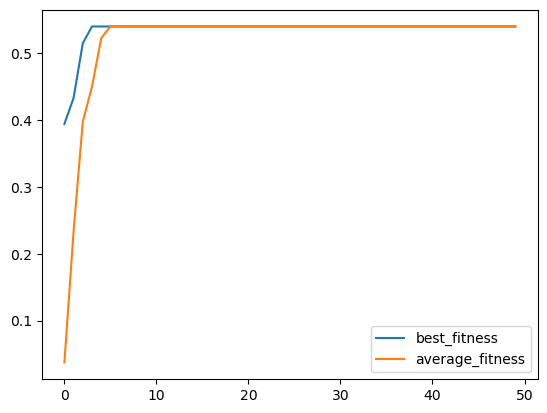

In [94]:
timesteps = 50
nodes = 50

G = nx.complete_graph(nodes)
G = nx.line_graph(G)

# assign random states
for n in G.nodes:
    r = np.random.randint(0, 2, N)
    G.nodes[n]["state"] = r
    # print(r)


average_fitness = []
best_fitness = []
unique_solutions = []


for t in range(timesteps):

    states_to_update = {}

    current_average_fitness = []
    current_best_fitness = 0
    # current_unique_solutions = set()


    for node in G.nodes:

        node_fitness = fitness(G.nodes[node]["state"])
        # print(f"{node=} {node_fitness=}")

        current_average_fitness.append(node_fitness)
        # current_unique_solutions.add(G.nodes[node]["state"].copy())

        if node_fitness > current_best_fitness:
            current_best_fitness = node_fitness

        best_neighbor = node
        best_neighbor_fitness = fitness(G.nodes[best_neighbor]["state"])

        for neighbor in nx.neighbors(G, node):

            neighbor_fitness = fitness(G.nodes[neighbor]["state"])
            # print(f"\t{neighbor=} {neighbor_fitness=}")

            if neighbor_fitness > best_neighbor_fitness:
                best_neighbor = neighbor
                best_neighbor_fitness = fitness(G.nodes[best_neighbor]["state"])
            # print(f"\t{best_neighbor=} {best_neighbor_fitness=}")

        
        if best_neighbor == node:
            new_state = random_bit_flip(G.nodes[node]["state"].copy())
            # print(f"\t{node=} testing new state")

            if fitness(new_state) > node_fitness:
                # print(f"\t{node=} changing {node_fitness=} to {fitness(new_state)=}")
                states_to_update[node] = new_state
            # else:
                # print(f"\t{node=} remaining {node_fitness=} {fitness(new_state)=}")

        else:
            # print(f"\t{node=} changing to {best_neighbor=}")
            states_to_update[node] = G.nodes[best_neighbor]["state"].copy()


    # print(f"{states_to_update=}")

    for key in states_to_update.keys():
        G.nodes[key]["state"] = states_to_update[key].copy()
        # print(f"updating {key=} {G.nodes[key]=}")


    best_fitness.append(current_best_fitness)
    average_fitness.append(np.mean(current_average_fitness))
    # unique_solutions.append(len(current_unique_solutions))

    # print()

    # print(f"{best_fitness=}\n{average_fitness=}\n")


fig, ax = plt.subplots(1, 1)

ax.plot(best_fitness, label="best_fitness")
ax.plot(average_fitness, label="average_fitness")

plt.legend()

plt.show()